# Anomaly Computation cross-check for $\mathbb{C}^3/\mathbb{Z}_N$ orbifolds

We compute the 1-form self-anomaly and refinements of via eta-invariants and cross-check it using toric intersection theory. Results are published: https://arxiv.org/abs/2512.17906

## Summary

The key function is `summarize_cyclic_model(order, weights, ...)`. For a cyclic toric model it displays:

1. the toric diagram and toric divisor data,
2. the non-zero triple intersection ring,
3. a non-compact divisor representative matched to Kawasaki normalization,
4. its charge,
5. the bulk/intersection eta quantity,
6. the Degeratu eta quantity, and
7. the integral Dirac index measuring the difference.


In [ ]:
%matplotlib inline
from IPython.display import display

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from fractions import Fraction
from functools import lru_cache, reduce
from collections import defaultdict
import itertools
import math

import matplotlib.pyplot as plt
import mpmath as mp
import numpy as np
import pandas as pd
from scipy.spatial import Delaunay


# -----------------------------------------------------------------------------
# Small exact-arithmetic helpers
# -----------------------------------------------------------------------------

def frac_str(x) -> str:
    return str(x) if isinstance(x, Fraction) else str(Fraction(x))


def lcm(a: int, b: int) -> int:
    if a == 0 or b == 0:
        return 0
    return abs(a * b) // math.gcd(a, b)


def lcmm(*args: int) -> int:
    return reduce(lcm, args, 1)


def gcdm(*args: int) -> int:
    return reduce(math.gcd, args)


def positive_residue(x: int, n: int) -> int:
    r = x % n
    return r if r != 0 else n


def mod1(x) -> Fraction:
    x = Fraction(x)
    return Fraction(x.numerator % x.denominator, x.denominator)


def units_mod(n: int) -> list[int]:
    return [u for u in range(1, n) if math.gcd(u, n) == 1]


def det3(M) -> Fraction:
    return (
        M[0][0] * (M[1][1] * M[2][2] - M[1][2] * M[2][1])
        - M[0][1] * (M[1][0] * M[2][2] - M[1][2] * M[2][0])
        + M[0][2] * (M[1][0] * M[2][1] - M[1][1] * M[2][0])
    )


def solve3_fraction(A, b) -> tuple[Fraction, Fraction, Fraction]:
    A = [[Fraction(v) for v in row] for row in A]
    b = [Fraction(v) for v in b]
    D = det3(A)
    if D == 0:
        raise ZeroDivisionError("Singular 3x3 system.")
    out = []
    for col in range(3):
        M = [row[:] for row in A]
        for r in range(3):
            M[r][col] = b[r]
        out.append(det3(M) / D)
    return tuple(out)


# -----------------------------------------------------------------------------
# Toric geometry for cyclic C^3/Z_N orbifolds
# -----------------------------------------------------------------------------

def canonical_cyclic_weights(order: int, weights) -> tuple[int, int, int]:
    """Return the lexicographically smallest representative equivalent to 1/N(1,a,b)
    with 1+a+b=N. This reproduces the toric presentation used in the Mathematica
    notebooks for cyclic Calabi-Yau orbifolds.
    """
    weights = tuple(int(positive_residue(w, order)) for w in weights)
    candidates = []
    for u in units_mod(order):
        scaled = tuple(positive_residue(u * w, order) for w in weights)
        for perm in set(itertools.permutations(scaled)):
            if perm[0] == 1 and sum(perm) == order:
                candidates.append(perm)
    if not candidates:
        raise ValueError(
            f"Could not find a canonical toric representative 1/{order}(1,a,b) equivalent to {weights}."
        )
    return sorted(set(candidates))[0]


def toric_outer_points(order: int, weights) -> tuple[list[tuple[int, int]], tuple[int, int, int]]:
    w = canonical_cyclic_weights(order, weights)
    _, a, b = w
    return [(-1, 0), (0, -1), (a, b)], w


def orient(a, b, c) -> int:
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])


def point_in_or_on_triangle(p, tri) -> bool:
    a, b, c = tri
    o = orient(a, b, c)
    if o == 0:
        return False
    s1 = orient(a, b, p)
    s2 = orient(b, c, p)
    s3 = orient(c, a, p)
    if o > 0:
        return s1 >= 0 and s2 >= 0 and s3 >= 0
    return s1 <= 0 and s2 <= 0 and s3 <= 0


def on_segment(p, a, b) -> bool:
    return orient(a, b, p) == 0 and min(a[0], b[0]) <= p[0] <= max(a[0], b[0]) and min(a[1], b[1]) <= p[1] <= max(a[1], b[1])


def lattice_points(tri) -> list[tuple[int, int]]:
    xs = [p[0] for p in tri]
    ys = [p[1] for p in tri]
    pts = []
    for x in range(min(xs), max(xs) + 1):
        for y in range(min(ys), max(ys) + 1):
            p = (x, y)
            if point_in_or_on_triangle(p, tri):
                pts.append(p)
    return sorted(pts)


def split_boundary_interior(points, outer):
    boundary = []
    interior = []
    for p in points:
        if any(on_segment(p, outer[i], outer[(i + 1) % 3]) for i in range(3)):
            boundary.append(p)
        else:
            interior.append(p)
    return boundary, interior


def triangulate_points(points) -> list[tuple[int, int, int]]:
    pts = np.array(points, dtype=float)
    tri = Delaunay(pts, qhull_options="QJ Pp")
    simplices = []
    seen = set()
    for simplex in tri.simplices:
        simplex = tuple(sorted(int(i) for i in simplex))
        coords = [tuple(points[i]) for i in simplex]
        if abs(orient(*coords)) == 0:
            continue
        if simplex not in seen:
            seen.add(simplex)
            simplices.append(simplex)
    return sorted(simplices)


def internal_edges(triangles):
    edge_to_tris = defaultdict(list)
    for t_idx, tri in enumerate(triangles):
        a, b, c = tri
        for e in [(a, b), (a, c), (b, c)]:
            edge_to_tris[tuple(sorted(e))].append(t_idx)
    return {e: ts for e, ts in edge_to_tris.items() if len(ts) == 2}


def solve_k_along_vector(v, w) -> Fraction:
    vx, vy = v
    wx, wy = w
    vals = []
    if vx != 0:
        vals.append(Fraction(-wx, vx))
    elif wx != 0:
        raise ValueError("No solution for k.")
    if vy != 0:
        vals.append(Fraction(-wy, vy))
    elif wy != 0:
        raise ValueError("No solution for k.")
    if not vals:
        raise ValueError("Degenerate shared edge.")
    if len(set(vals)) != 1:
        raise ValueError(f"Inconsistent k values {vals}")
    return vals[0]


@dataclass(frozen=True)
class CyclicToricModel:
    order: int
    weights_input: tuple[int, int, int]
    weights_canonical: tuple[int, int, int]
    outer_points: list[tuple[int, int]]
    points: list[tuple[int, int]]
    boundary_points: list[tuple[int, int]]
    interior_points: list[tuple[int, int]]
    triangulation: list[tuple[int, int, int]]
    compact_indices: tuple[int, ...]
    boundary_indices: tuple[int, ...]
    corner_indices: tuple[int, int, int]
    divisor_names: list[str]
    corner_expressions: dict[int, dict[int, Fraction]]
    intersection_ring: dict[tuple[int, int, int], Fraction]


def linear_equivalence_expressions(points, outer_corner_indices):
    """Express the three corner divisors in terms of the remaining divisors by
    solving the three standard toric linear equivalences. This is a fast exact
    replacement for the symbolic Mathematica Solve-based implementation.
    """
    corners = list(outer_corner_indices)
    others = [i for i in range(len(points)) if i not in corners]
    A = [
        [points[i][0] for i in corners],
        [points[i][1] for i in corners],
        [1, 1, 1],
    ]
    exprs = {i: {} for i in corners}
    for j in others:
        coeffs = solve3_fraction(A, [-points[j][0], -points[j][1], -1])
        for corner_i, coeff in zip(corners, coeffs):
            if coeff != 0:
                exprs[corner_i][j] = coeff
    return exprs


def full_intersection_ring(points, triangles, compact_indices, boundary_indices):
    """Efficient notebook-compatible triple intersection ring.

    The original Mathematica notebook constructs this in several symbolic passes.
    Here we compute it combinatorially:
      * distinct triples from maximal cones;
      * repeated-pair intersections from the unique internal edge shared by two triangles;
      * compact self-intersections via 12 - (# incident triangles), exactly as in the notebook;
      * non-compact self-intersections via (# distinct neighboring vertices) - 2, also as in the notebook.
    """
    I = defaultdict(Fraction)

    # Distinct triples: every unimodular cone contributes 1.
    for tri in triangles:
        I[tuple(sorted(tri))] += Fraction(1)

    # Two-equal-one-different triples from shared internal edges.
    for (i, j), tris in internal_edges(triangles).items():
        t1, t2 = triangles[tris[0]], triangles[tris[1]]
        r = next(v for v in t1 if v not in (i, j))
        s = next(v for v in t2 if v not in (i, j))
        pi, pj, pr, ps = points[i], points[j], points[r], points[s]
        dijj = solve_k_along_vector(
            (pj[0] - pi[0], pj[1] - pi[1]),
            (pr[0] - pi[0] + ps[0] - pi[0], pr[1] - pi[1] + ps[1] - pi[1]),
        )
        diij = solve_k_along_vector(
            (pi[0] - pj[0], pi[1] - pj[1]),
            (pr[0] - pj[0] + ps[0] - pj[0], pr[1] - pj[1] + ps[1] - pj[1]),
        )
        if dijj != 0:
            I[tuple(sorted((i, j, j)))] = dijj
        if diij != 0:
            I[tuple(sorted((i, i, j)))] = diij

    # Self intersections.
    incidence = defaultdict(int)
    for tri in triangles:
        for v in tri:
            incidence[v] += 1

    for i in compact_indices:
        val = Fraction(12 - incidence[i])
        if val != 0:
            I[(i, i, i)] = val

    for i in boundary_indices:
        neigh = sorted(set(v for tri in triangles if i in tri for v in tri if v != i))
        val = Fraction(len(neigh) - 2)
        if val != 0:
            I[(i, i, i)] = val

    return dict(sorted((k, v) for k, v in I.items() if v != 0))


def build_model(order: int, weights) -> CyclicToricModel:
    outer, canon = toric_outer_points(order, weights)
    pts = lattice_points(outer)
    boundary, interior = split_boundary_interior(pts, outer)
    tri = triangulate_points(pts)
    point_to_idx = {p: i for i, p in enumerate(pts)}
    corner_indices = tuple(point_to_idx[p] for p in outer)
    boundary_indices = tuple(i for i, p in enumerate(pts) if p in boundary)
    compact_indices = tuple(i for i, p in enumerate(pts) if p in interior)

    names = []
    e = 1
    b = 1
    corner_pos = {idx: pos + 1 for pos, idx in enumerate(corner_indices)}
    for i in range(len(pts)):
        if i in compact_indices:
            names.append(f"E{e}")
            e += 1
        elif i in corner_indices:
            names.append(f"Z{corner_pos[i]}")
        else:
            names.append(f"B{b}")
            b += 1

    return CyclicToricModel(
        order=order,
        weights_input=tuple(int(positive_residue(w, order)) for w in weights),
        weights_canonical=canon,
        outer_points=outer,
        points=pts,
        boundary_points=boundary,
        interior_points=interior,
        triangulation=tri,
        compact_indices=compact_indices,
        boundary_indices=boundary_indices,
        corner_indices=corner_indices,
        divisor_names=names,
        corner_expressions=linear_equivalence_expressions(pts, corner_indices),
        intersection_ring=full_intersection_ring(pts, tri, compact_indices, boundary_indices),
    )


def toric_data_dataframe(model: CyclicToricModel) -> pd.DataFrame:
    rows = []
    for i, p in enumerate(model.points):
        rows.append(
            {
                "index": i,
                "point": p,
                "divisor": model.divisor_names[i],
                "type": "compact" if i in model.compact_indices else ("corner" if i in model.corner_indices else "boundary"),
            }
        )
    return pd.DataFrame(rows)


def ring_dataframe(model: CyclicToricModel) -> pd.DataFrame:
    rows = []
    for (i, j, k), val in model.intersection_ring.items():
        labels = [model.divisor_names[i], model.divisor_names[j], model.divisor_names[k]]
        mult = defaultdict(int)
        for lab in labels:
            mult[lab] += 1
        monomial = "·".join(f"{lab}^{m}" if m > 1 else lab for lab, m in sorted(mult.items()))
        rows.append({"indices": (i, j, k), "intersection": monomial, "value": frac_str(val)})
    return pd.DataFrame(rows).sort_values(["indices"]).reset_index(drop=True)


def plot_toric_diagram(model: CyclicToricModel, title: str | None = None):
    fig, ax = plt.subplots(figsize=(5.4, 5.4))
    for tri in model.triangulation:
        pts = [model.points[i] for i in tri] + [model.points[tri[0]]]
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        ax.plot(xs, ys, lw=1)

    for i, p in enumerate(model.points):
        if i in model.compact_indices:
            marker = "o"
        elif i in model.corner_indices:
            marker = "s"
        else:
            marker = "^"
        ax.scatter([p[0]], [p[1]], marker=marker, s=70)
        ax.text(p[0] + 0.08, p[1] + 0.08, model.divisor_names[i], fontsize=9)

    xs = [p[0] for p in model.points]
    ys = [p[1] for p in model.points]
    ax.set_xlim(min(xs) - 0.8, max(xs) + 0.8)
    ax.set_ylim(min(ys) - 0.8, max(ys) + 0.8)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title or f"Toric diagram for C^3/Z_{model.order}{model.weights_canonical}")
    fig.tight_layout()
    return fig


# -----------------------------------------------------------------------------
# Bulk intersections, Kawasaki data and eta-invariants
# -----------------------------------------------------------------------------

def format_divisor(expr: dict[int, Fraction], model: CyclicToricModel) -> str:
    if not expr:
        return "0"
    parts = []
    for i, coeff in sorted(expr.items()):
        lab = model.divisor_names[i]
        if coeff == 1:
            parts.append(lab)
        elif coeff == -1:
            parts.append(f"-{lab}")
        else:
            parts.append(f"{coeff}·{lab}")
    return " + ".join(parts).replace("+ -", "- ")


def scale_expr(expr: dict[int, Fraction], factor: int | Fraction) -> dict[int, Fraction]:
    return {k: Fraction(factor) * v for k, v in expr.items()}


def triple_eval(expr_a, expr_b, expr_c, intersection_ring) -> Fraction:
    out = Fraction(0)
    for i, ai in expr_a.items():
        for j, bj in expr_b.items():
            for k, ck in expr_c.items():
                out += ai * bj * ck * intersection_ring.get(tuple(sorted((i, j, k))), Fraction(0))
    return out


def p1_pairing(expr, model: CyclicToricModel) -> Fraction:
    out = Fraction(0)
    for j in range(len(model.points)):
        out += triple_eval(expr, {j: Fraction(1)}, {j: Fraction(1)}, model.intersection_ring)
    return out


def bulk_terms(expr, model: CyclicToricModel) -> dict[str, Fraction]:
    cubic = triple_eval(expr, expr, expr, model.intersection_ring)
    p1 = p1_pairing(expr, model)
    beta = Fraction(cubic, 6)
    gamma = Fraction(-p1, 24)
    alpha = beta + gamma
    return {
        "cubic": cubic,
        "p1_pairing": p1,
        "beta_bulk": beta,
        "gamma_bulk": gamma,
        "alpha_bulk": alpha,
    }


def kawasaki_charge_raw(weights) -> int:
    w1, w2, w3 = weights
    return lcmm(w1 * w2 // math.gcd(w1, w2), w2 * w3 // math.gcd(w2, w3), w1 * w3 // math.gcd(w1, w3))


def kawasaki_charge_mod(order: int, weights) -> int:
    return kawasaki_charge_raw(weights) % order


def kawasaki_r(order: int, weights) -> int:
    w1, w2, w3 = weights
    return w1 * w2 * w3 * order // gcdm(w1, w2, w3, order)


def kawasaki_boundary_cubic(order: int, weights) -> Fraction:
    return Fraction(kawasaki_charge_raw(weights) ** 3, kawasaki_r(order, weights))


@lru_cache(maxsize=None)
def eta_s5_cyclic_cached(order: int, weights: tuple[int, int, int], charge: int, overall_sign: int = 1, dps: int = 110) -> Fraction:
    """Return alpha = 1/2 eta_{D/}(S^5/Z_N) in the conventions of the paper.

    The calculation is numerical at high precision and then rationalized. For the
    examples relevant here the result is always a simple rational number.
    """
    mp.mp.dps = dps
    omega = mp.e ** (2 * mp.pi * 1j / order)
    total = mp.mpc(0)
    for k in range(1, order):
        if any((wk * k) % order == 0 for wk in weights):
            continue  # not fixed-point free
        numer = overall_sign * ((-1) ** k) * omega ** (k * charge)
        denom = 1
        for wk in weights:
            denom *= omega ** (-k * wk / 2) - omega ** (k * wk / 2)
        total += numer / denom
    total /= order
    if abs(mp.im(total)) > mp.mpf(10) ** (-(dps // 3)):
        raise ValueError(f"Unexpected imaginary residue in eta computation: {total}")
    return Fraction(mp.nstr(mp.re(total), n=dps)).limit_denominator(order ** 6)


def eta_s5_cyclic(order: int, weights, charge: int, overall_sign: int = 1) -> Fraction:
    weights = tuple(int(positive_residue(w, order)) for w in weights)
    charge = int(charge % order)
    return eta_s5_cyclic_cached(order, weights, charge, overall_sign)


def beta_gamma_from_eta(order: int, weights, charge: int, overall_sign: int = 1) -> tuple[Fraction, Fraction]:
    a1 = eta_s5_cyclic(order, weights, charge, overall_sign)
    a2 = eta_s5_cyclic(order, weights, (2 * charge) % order, overall_sign)
    beta = Fraction(1, 6) * a2 - Fraction(1, 3) * a1
    gamma = Fraction(-1, 6) * a2 + Fraction(4, 3) * a1
    return beta, gamma


def eta_s3_bar_raw(order: int, weights, charge: int) -> Fraction:
    """Carry-over utility from the original notebooks: raw 1/2 eta_{bar d} on S^3/Z_N(r,s).
    The mixed anomaly in section 4 of the paper is the twisted minus untwisted difference.
    """
    r, s = weights
    mp.mp.dps = 90
    omega = mp.e ** (2 * mp.pi * 1j / order)
    total = mp.mpc(0)
    for k in range(1, order):
        total += omega ** (charge * k) / ((1 - omega ** (r * k)) * (1 - omega ** (s * k)))
    total /= order
    if abs(mp.im(total)) > mp.mpf('1e-25'):
        raise ValueError(f"Unexpected imaginary residue in S^3 eta computation: {total}")
    return Fraction(mp.nstr(mp.re(total), n=90)).limit_denominator(order ** 6)


def alpha_s3_bar(order: int, weights, charge: int) -> Fraction:
    return eta_s3_bar_raw(order, weights, charge) - eta_s3_bar_raw(order, weights, 0)


# -----------------------------------------------------------------------------
# Choosing a convenient non-compact divisor representative
# -----------------------------------------------------------------------------

def candidate_divisors(model: CyclicToricModel):
    return [(idx, expr) for idx, expr in model.corner_expressions.items() if set(expr).issubset(set(model.compact_indices))]


def matching_scaled_divisors(model: CyclicToricModel, target_charge: int | None = None, max_scale: int | None = None):
    if target_charge is None:
        target_charge = kawasaki_charge_mod(model.order, model.weights_input)
    if max_scale is None:
        max_scale = max(2 * model.order, 12)

    target_alpha = mod1(eta_s5_cyclic(model.order, model.weights_input, target_charge))
    target_cubic = mod1(kawasaki_boundary_cubic(model.order, model.weights_input))
    out = []
    for idx, expr in candidate_divisors(model):
        for scale in range(-max_scale, max_scale + 1):
            if scale == 0:
                continue
            scaled = scale_expr(expr, scale)
            bulk = bulk_terms(scaled, model)
            if mod1(bulk["alpha_bulk"]) == target_alpha and mod1(bulk["cubic"]) == target_cubic:
                out.append((idx, scale, scaled, bulk))
    return out


def choose_divisor(model: CyclicToricModel, preferred_corner: str | int = "auto", preferred_sign: str = "positive"):
    matches = matching_scaled_divisors(model)
    if not matches:
        raise ValueError("Could not find a divisor/scale matching both Kawasaki and Degeratu.")

    if preferred_corner != "auto":
        if isinstance(preferred_corner, str) and preferred_corner.upper().startswith("Z"):
            target = preferred_corner.upper()
            subset = [m for m in matches if model.divisor_names[m[0]].upper() == target]
        else:
            subset = [m for m in matches if m[0] == preferred_corner]
        if subset:
            matches = subset

    if preferred_sign == "positive":
        key = lambda m: (m[1] < 0, abs(m[1]), m[0])
    elif preferred_sign == "negative":
        key = lambda m: (m[1] > 0, abs(m[1]), m[0])
    else:
        key = lambda m: (abs(m[1]), m[0], m[1])
    return sorted(matches, key=key)[0]


# -----------------------------------------------------------------------------
# Useful physics metadata for non-isolated singularities
# -----------------------------------------------------------------------------

def singularity_profile(order: int, weights) -> dict[str, object]:
    gks = tuple(math.gcd(order, w) for w in weights)
    gprod = math.prod(gks)
    one_form_order = order // gprod
    flavor = " ⊕ ".join(f"su({g})" for g in gks if g > 1) or "none"
    return {
        "gcds": gks,
        "g_product": gprod,
        "one_form_order": one_form_order,
        "flavor_algebra": flavor,
    }


def flavor_anomalies(order: int, weights) -> dict[str, object]:
    prof = singularity_profile(order, weights)
    q = kawasaki_charge_mod(order, weights)
    gks = list(prof["gcds"])
    deltas = []
    epsilons = []
    for k in range(3):
        i, j = [m for m in range(3) if m != k]
        if gks[k] > 1:
            deltas.append((k + 1, Fraction(q * gks[i] * gks[j], order)))
            epsilons.append((k + 1, Fraction(weights[k], order)))
    return {"delta_k": deltas, "epsilon_k": epsilons}


# -----------------------------------------------------------------------------
# Main user-facing summary function
# -----------------------------------------------------------------------------

def summarize_cyclic_model(
    order: int,
    weights,
    *,
    preferred_corner: str | int = "auto",
    preferred_sign: str = "positive",
    show_plot: bool = True,
    show_ring: bool = True,
) -> dict[str, object]:
    """Main summary function requested by the user.

    For a cyclic toric model C^3/Z_N it prints and returns:
      - toric diagram data,
      - the intersection ring,
      - a convenient non-compact divisor representative,
      - its charge,
      - the bulk/intersection eta-invariant,
      - the boundary/Degeratu eta-invariant,
      - and the integral Dirac index measuring their difference.
    """
    model = build_model(order, weights)
    idx, scale, scaled_expr, bulk = choose_divisor(model, preferred_corner=preferred_corner, preferred_sign=preferred_sign)

    q_raw = kawasaki_charge_raw(model.weights_input)
    q_mod = kawasaki_charge_mod(model.order, model.weights_input)
    eta = eta_s5_cyclic(model.order, model.weights_input, q_mod)
    beta_eta, gamma_eta = beta_gamma_from_eta(model.order, model.weights_input, q_mod)
    profile = singularity_profile(model.order, model.weights_input)

    info = {
        "input weights": model.weights_input,
        "canonical weights": model.weights_canonical,
        "group order N": model.order,
        "1-form group": f"Z_{profile['one_form_order']}",
        "flavor algebra": profile["flavor_algebra"],
        "gcds (g1,g2,g3)": profile["gcds"],
        "chosen divisor": f"{scale} × {model.divisor_names[idx]} = {format_divisor(scaled_expr, model)}",
        "Kawasaki charge raw": q_raw,
        "charge used in Degeratu (mod N)": q_mod,
        "bulk cubic D^3 mod 1": mod1(bulk["cubic"]),
        "Kawasaki cubic mod 1": mod1(kawasaki_boundary_cubic(model.order, model.weights_input)),
        "intersection eta (bulk α)": bulk["alpha_bulk"],
        "Degeratu eta α = 1/2 η": eta,
        "Dirac index (bulk - boundary)": bulk["alpha_bulk"] - eta,
        "canonical β from η": beta_eta,
        "canonical γ from η": gamma_eta,
        "bulk/eta match mod 1": mod1(bulk["alpha_bulk"]) == mod1(eta),
    }

    if show_plot:
        plot_toric_diagram(model, title=f"C^3/Z_{model.order}{model.weights_canonical}")
        plt.show()

    display_df = pd.DataFrame(
        {
            "quantity": list(info.keys()),
            "value": [frac_str(v) if isinstance(v, Fraction) else str(v) for v in info.values()],
        }
    )
    print(display_df.to_string(index=False))
    print("\nToric divisors / lattice points:")
    print(toric_data_dataframe(model).to_string(index=False))
    print("\nCorner divisors expressed in the compact basis:")
    for corner_idx, expr in model.corner_expressions.items():
        print(f"  {model.divisor_names[corner_idx]} = {format_divisor(expr, model)}")
    if show_ring:
        print("\nNon-zero triple intersections:")
        print(ring_dataframe(model)[["intersection", "value"]].to_string(index=False))
    if profile["flavor_algebra"] != "none":
        print("\nNon-isolated flavor-anomaly data:")
        print(flavor_anomalies(model.order, model.weights_input))

    return {
        "model": model,
        "summary": info,
        "intersection_ring": ring_dataframe(model),
    }


# -----------------------------------------------------------------------------
# Convenience tables used in the executed notebook
# -----------------------------------------------------------------------------

def family_check_isolated(n_max: int = 4) -> pd.DataFrame:
    rows = []
    for n in range(0, n_max + 1):
        order = 2 * n + 3
        weights = (1, 1, 2 * n + 1)
        model = build_model(order, weights)
        idx, scale, expr, bulk = choose_divisor(model, preferred_sign="positive")
        q = kawasaki_charge_mod(order, weights)
        eta = eta_s5_cyclic(order, weights, q)
        rows.append(
            {
                "n": n,
                "model": f"C^3/Z_{order}{weights}",
                "divisor": f"{scale}×{model.divisor_names[idx]}",
                "q": q,
                "bulk α mod 1": frac_str(mod1(bulk["alpha_bulk"])),
                "Degeratu α mod 1": frac_str(mod1(eta)),
                "Dirac index": frac_str(bulk["alpha_bulk"] - eta),
                "match": mod1(bulk["alpha_bulk"]) == mod1(eta),
            }
        )
    return pd.DataFrame(rows)


def family_check_nonisolated(n_min: int = 1, n_max: int = 5) -> pd.DataFrame:
    rows = []
    for n in range(n_min, n_max + 1):
        order = 2 * n + 2
        weights = (1, 1, 2 * n)
        model = build_model(order, weights)
        idx, scale, expr, bulk = choose_divisor(model, preferred_sign="negative")
        q = kawasaki_charge_mod(order, weights)
        eta = eta_s5_cyclic(order, weights, q)
        prof = singularity_profile(order, weights)
        rows.append(
            {
                "n": n,
                "model": f"C^3/Z_{order}{weights}",
                "1-form": f"Z_{prof['one_form_order']}",
                "flavor": prof["flavor_algebra"],
                "divisor": f"{scale}×{model.divisor_names[idx]}",
                "q": q,
                "bulk α mod 1": frac_str(mod1(bulk["alpha_bulk"])),
                "Degeratu α mod 1": frac_str(mod1(eta)),
                "match": mod1(bulk["alpha_bulk"]) == mod1(eta),
            }
        )
    return pd.DataFrame(rows)


def lens_space_eta_table(orders=(3, 5, 7)) -> pd.DataFrame:
    rows = []
    for N in orders:
        raw = eta_s3_bar_raw(N, (1, N - 1), 1)
        alpha = alpha_s3_bar(N, (1, N - 1), 1)
        rows.append(
            {
                "N": N,
                "weights": (1, N - 1),
                "raw 1/2 eta_bar(Q=1)": frac_str(raw),
                "twisted-minus-untwisted anomaly": frac_str(alpha),
            }
        )
    return pd.DataFrame(rows)


def refined_eta_table(order: int, weights) -> pd.DataFrame:
    rows = []
    for Q in range(order):
        rows.append(
            {
                "Q mod N": Q,
                "alpha_tilde(Q) = 1/2 eta": frac_str(eta_s5_cyclic(order, weights, Q)),
            }
        )
    return pd.DataFrame(rows)


# -----------------------------------------------------------------------------
# Lightweight compatibility aliases with the Mathematica notebooks
# -----------------------------------------------------------------------------

def EtaInvariantS5(order: int, weights, charge: int, overall_sign: int = 1) -> Fraction:
    return eta_s5_cyclic(order, weights, charge, overall_sign)


def EtaInvariantS3(order: int, weights, charge: int) -> Fraction:
    return eta_s3_bar_raw(order, weights, charge)


def KawasakiBoundary(weights, order: int) -> Fraction:
    return kawasaki_boundary_cubic(order, weights)


def KawasakiCharge(weights, order: int) -> int:
    return kawasaki_charge_mod(order, weights)


def DiracIndex(order: int, weights, *, preferred_corner: str | int = "auto", preferred_sign: str = "positive") -> Fraction:
    data = summarize_cyclic_model(order, weights, preferred_corner=preferred_corner, preferred_sign=preferred_sign, show_plot=False, show_ring=False)
    return data["summary"]["Dirac index (bulk - boundary)"]


# -----------------------------------------------------------------------------
# Small regression harness
# -----------------------------------------------------------------------------

def _regression_rows():
    rows = []
    examples = [
        (5, (1, 1, 3), "isolated"),
        (17, (1, 3, 13), "isolated"),
        (6, (1, 1, 4), "non-isolated"),
    ]
    for order, weights, kind in examples:
        model = build_model(order, weights)
        preferred_sign = "negative" if kind == "non-isolated" else "positive"
        idx, scale, expr, bulk = choose_divisor(model, preferred_sign=preferred_sign)
        q = kawasaki_charge_mod(order, weights)
        eta = eta_s5_cyclic(order, weights, q)
        rows.append(
            {
                "kind": kind,
                "model": f"C^3/Z_{order}{weights}",
                "divisor": f"{scale}×{model.divisor_names[idx]}",
                "charge q": q,
                "bulk α mod 1": frac_str(mod1(bulk["alpha_bulk"])),
                "eta α mod 1": frac_str(mod1(eta)),
                "Dirac index": frac_str(bulk["alpha_bulk"] - eta),
                "Kawasaki cubic mod 1": frac_str(mod1(bulk["cubic"])),
                "match": mod1(bulk["alpha_bulk"]) == mod1(eta),
            }
        )
    return pd.DataFrame(rows)


## Worked isolated example: $\mathbb{C}^3/\mathbb{Z}_5(1,1,3)$

This small example shows the full toric data and the full non-zero intersection ring.

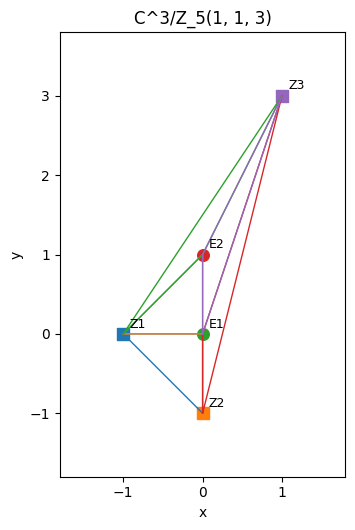

                       quantity                     value
                  input weights                 (1, 1, 3)
              canonical weights                 (1, 1, 3)
                  group order N                         5
                   1-form group                       Z_5
                 flavor algebra                      none
                gcds (g1,g2,g3)                 (1, 1, 1)
                 chosen divisor 2 × Z1 = -2/5·E1 - 4/5·E2
            Kawasaki charge raw                         3
charge used in Degeratu (mod N)                         3
           bulk cubic D^3 mod 1                       4/5
           Kawasaki cubic mod 1                       4/5
      intersection eta (bulk α)                         0
         Degeratu eta α = 1/2 η                         0
  Dirac index (bulk - boundary)                         0
             canonical β from η                     -1/30
             canonical γ from η                      1/30
           bul

In [ ]:
example_5 = summarize_cyclic_model(5, (1, 1, 3), show_plot=True, show_ring=True)

## Worked isolated example: $\mathbb{C}^3/\mathbb{Z}_{17}(1,3,13)$

This is one of the examples with non-trivial integral Dirac index. To keep the notebook readable, the full ring printout is suppressed here.

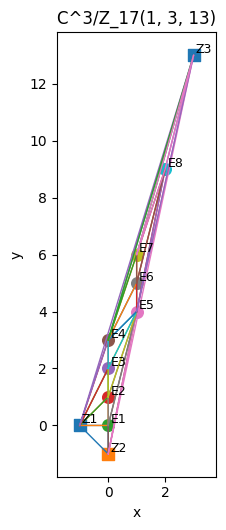

                       quantity                                                                                         value
                  input weights                                                                                    (1, 3, 13)
              canonical weights                                                                                    (1, 3, 13)
                  group order N                                                                                            17
                   1-form group                                                                                          Z_17
                 flavor algebra                                                                                          none
                gcds (g1,g2,g3)                                                                                     (1, 1, 1)
                 chosen divisor 4 × Z1 = -12/17·E1 - 24/17·E2 - 36/17·E3 - 48/17·E4 - 4/17·E5 - 16/17·E6 - 28/17·E7 - 

In [ ]:
example_17 = summarize_cyclic_model(17, (1, 3, 13), show_plot=True, show_ring=False)

## Worked non-isolated example: $\mathbb{C}^3/\mathbb{Z}_6(1,1,4)$

This example also prints the flavor-algebra data and the mixed flavor-anomaly coefficients carried over from the notebooks.

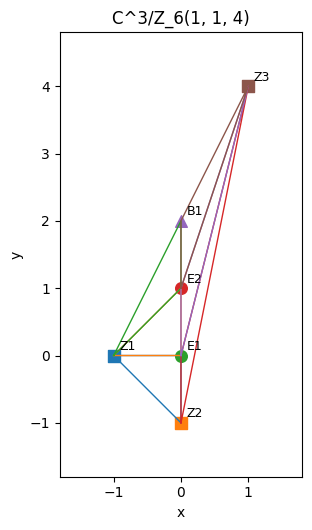

                       quantity                     value
                  input weights                 (1, 1, 4)
              canonical weights                 (1, 1, 4)
                  group order N                         6
                   1-form group                       Z_3
                 flavor algebra                     su(2)
                gcds (g1,g2,g3)                 (1, 1, 2)
                 chosen divisor -1 × Z2 = 2/3·E1 + 1/3·E2
            Kawasaki charge raw                         4
charge used in Degeratu (mod N)                         4
           bulk cubic D^3 mod 1                       2/3
           Kawasaki cubic mod 1                       2/3
      intersection eta (bulk α)                       1/9
         Degeratu eta α = 1/2 η                       1/9
  Dirac index (bulk - boundary)                         0
             canonical β from η                     -1/18
             canonical γ from η                       1/6
           bul

In [ ]:
example_6 = summarize_cyclic_model(6, (1, 1, 4), preferred_sign='negative', show_plot=True, show_ring=True)

In [ ]:
display(family_check_isolated())

display(family_check_nonisolated())

,n,model,divisor,q,bulk α mod 1,Degeratu α mod 1,Dirac index,match
0,0,"C^3/Z_3(1, 1, 1)",2×Z1,1,8/9,8/9,0,True
1,1,"C^3/Z_5(1, 1, 3)",2×Z1,3,0,0,0,True
2,2,"C^3/Z_7(1, 1, 5)",2×Z1,5,1/7,1/7,0,True
3,3,"C^3/Z_9(1, 1, 7)",2×Z1,7,8/27,8/27,0,True
4,4,"C^3/Z_11(1, 1, 9)",2×Z1,9,5/11,5/11,0,True


,n,model,1-form,flavor,divisor,q,bulk α mod 1,Degeratu α mod 1,match
0,1,"C^3/Z_4(1, 1, 2)",Z_2,su(2),-1×Z2,2,0,0,True
1,2,"C^3/Z_6(1, 1, 4)",Z_3,su(2),-1×Z2,4,1/9,1/9,True
2,3,"C^3/Z_8(1, 1, 6)",Z_4,su(2),-1×Z2,6,1/4,1/4,True
3,4,"C^3/Z_10(1, 1, 8)",Z_5,su(2),-1×Z2,8,2/5,2/5,True
4,5,"C^3/Z_12(1, 1, 10)",Z_6,su(2),-1×Z2,10,5/9,5/9,True


## Carry-over utility: $S^3/\mathbb{Z}_N$ twisted $\bar\partial$ eta

This reproduces the lens-space computation used for the 7D/6D examples.

In [ ]:
display(lens_space_eta_table((3, 5, 7)))

,N,weights,raw 1/2 eta_bar(Q=1),twisted-minus-untwisted anomaly
0,3,"(1, 2)",-1/9,-1/3
1,5,"(1, 4)",0,-2/5
2,7,"(1, 6)",1/7,-3/7


## Carry-over utility: refined charges on singular boundaries

For a singular boundary one can evaluate $\widetilde{\alpha}(Q)=\tfrac12\eta(Q)$ for all charges, not only the line-bundle charges in the 1-form subgroup.

In [ ]:
display(refined_eta_table(6, (1, 1, 4)))

,Q mod N,alpha_tilde(Q) = 1/2 eta
0,0,0
1,1,-2/9
2,2,-1/9
3,3,0
4,4,1/9
5,5,2/9
